In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.odr import Model, Data, RealData, ODR
from scipy import stats
import warnings

warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

In [4]:
data_d = "/home/lucytian/data/1_Single_Cell_PRS/2_cV2F/mvp_afr_0.9_0.01/20231221/406k_geno_v2_UKB_18PCs/fit_w_val"
traits = ['INI30120', 'INI50030700', 'INI1003063', 'INI20030780']
dfs = []

for tr in traits:

    if tr == "INI20030780":
        baseline_path = f"{data_d}/baseline/{tr}/exclude_APOE/snpnet.eval.tsv.gz"
    else:
        baseline_path = f"{data_d}/baseline/{tr}/snpnet.eval.tsv.gz"

    found_any = False

    # 🔹 Baseline
    if os.path.exists(baseline_path):
        baseline = pd.read_csv(baseline_path, sep='\t', compression='gzip')
        baseline['annot'] = 'baseline_LD'
        dfs.append(baseline)
        found_any = True
    else:
        print(f"[MISSING] Baseline file for {tr}")

In [5]:
baseline = pd.concat(dfs)
baseline = baseline[(baseline['population'] == 'Afr') & (baseline['split'] == 'test') & (baseline['model'] == 'PGS')]

In [6]:
baseline['Method'] = 'PRISM'
baseline = baseline[['#response', 'Method', 'eval', 'l_eval', 'u_eval', 'P', 'n']]
baseline['#response'] = ['INI30120', 'INI50030700', 'INI1003063', 'INI20030780 (exclude APOE)']
baseline['n'] = [1154, 1134, 1078, 1130]
baseline = baseline.rename(columns = {'#response': 'Phenotype'})


df = pd.read_csv('~/data/1_Single_Cell_PRS/2_cV2F/benchmarking.tsv', sep='\t')
vary_method = pd.concat([df[df['Method'] != 'PRISM'], baseline])
vary_method = vary_method[vary_method['Method'] != 'IMPACT']
vary_method['Method']=['Polypred+']*5 + ['SBayesRC-multi']*5 + ['PRISM']*4
vary_method = vary_method[vary_method['Phenotype'] != 'INI20030780']

In [8]:
tissue_trait_dict = {'INI50030700': 'eGFR', 'INI1003063': 'FEV1/FVC Ratio', 'INI20030780 (exclude APOE)': 'LDL-C (excl. APOE)', 'INI30120' : 'Lymphocyte Count'}

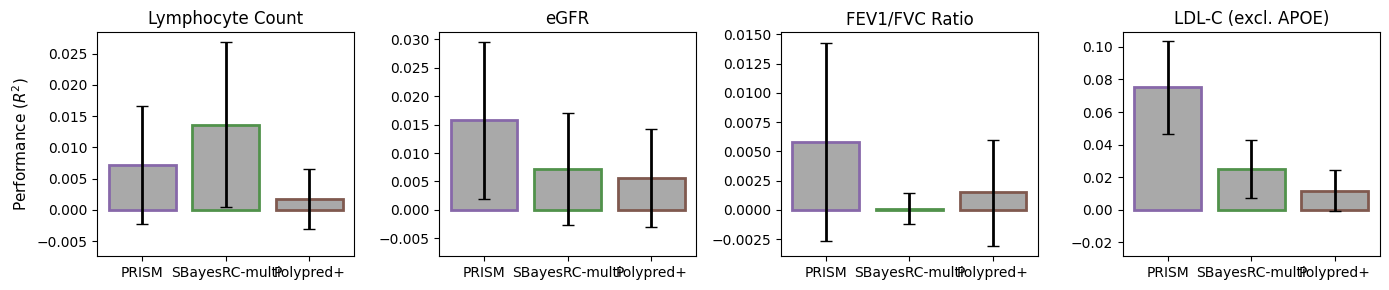

In [9]:
# === Plotting settings ===
order = ["PRISM", "SBayesRC-multi", "Polypred+"]
colors = ["#8768a9", "#51924b", "#80594f"]

edgecolor_dict = dict(zip(order, colors))

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes = axes.flatten()

# === Generate subplots ===
for i, (code, trait) in enumerate(tissue_trait_dict.items()):
    ax = axes[i]
    df_trait = vary_method[vary_method["Phenotype"] == code].copy()

    # Compute error bars
    df_trait["err_lower"] = df_trait["eval"] - df_trait["l_eval"]
    df_trait["err_upper"] = df_trait["u_eval"] - df_trait["eval"]

    # Reindex to keep order stable
    df_indexed = (
        df_trait
        .set_index("Method")
        .reindex(order)
        .reset_index()
    )

    sns.barplot(
        data=df_indexed,
        x="Method", y="eval",
        order=order,
        color='#A9A9A9',
        ax=ax,
        capsize=0,
        edgecolor=None
    )
    
    for patch, method in zip(ax.patches, order):
        patch.set_edgecolor(edgecolor_dict[method])
        patch.set_linewidth(2)
    

    ax.errorbar(
        x=range(len(order)),
        y=df_indexed["eval"],
        yerr=[
            df_indexed["err_lower"],
            df_indexed["err_upper"]
        ],
        fmt="none",
        ecolor="black",
        elinewidth=2,
        capsize=4
    )

    ax.set_title(trait, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Performance ($R^2$)" if i == 0 else "", fontsize=11)
    ax.tick_params(axis="x", labelrotation=0)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# === Align zero across panels without cropping min/max ===
valid_axes = axes[:len(tissue_trait_dict)]

ylims = [ax.get_ylim() for ax in valid_axes]

zero_positions = [
    (0 - ymin) / (ymax - ymin)
    for ymin, ymax in ylims
]

target = max(zero_positions)

for ax, (ymin, ymax) in zip(valid_axes, ylims):
    new_span = max(
        (0 - ymin) / target,
        (ymax - 0) / (1 - target)
    )

    new_ymin = 0 - target * new_span
    new_ymax = 0 + (1 - target) * new_span

    ax.set_ylim(new_ymin, new_ymax)
    
# Optional visual check
# for ax in valid_axes:
#     ax.axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
#plt.savefig("pgs_var.pdf", bbox_inches="tight")
plt.show()